In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import html

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity

In [35]:
# Load Marc's TTRPG dataset
ttrpg_df = pd.read_csv("../marc/ttrpg_database_final.csv")

# Load board game dataset
boardgame_df = pd.read_csv("../q/shortened_dataset.csv")

print("TTRPG shape:", ttrpg_df.shape)
print("TTRPG columns:", ttrpg_df.columns.tolist())

print("\nBoard game shape:", boardgame_df.shape)
print("Board game columns:", boardgame_df.columns.tolist())

display(ttrpg_df.head())
display(boardgame_df.head())

TTRPG shape: (10000, 5)
TTRPG columns: ['Name', 'Description', 'Average Score', 'Number of Reviews', 'Publishing Year']

Board game shape: (10000, 4)
Board game columns: ['Unnamed: 0', 'name', 'description', 'Average']


,Name,Description,Average Score,Number of Reviews,Publishing Year
0,The Strange,Publisher Blurb: Beneath the orbits and atoms ...,7.86486,37,2014
1,InSpectres,Fighting the Forces of Darkness so you don't h...,7.57355,138,2004
2,Dungeons & Dragons Expert Set,The first version of the D&D Expert Set. It co...,7.97881,151,1981
3,The Character Compendium,An unofficial supplement for Warhammer Fantasy...,8.09375,16,2013
4,The Elves of Alfheim,"""This is the first Gazetteer to outline a non-...",7.24878,41,1988


,Unnamed: 0,name,description,Average
0,0,Pandemic,"In Pandemic, several virulent diseases have br...",7.59
1,1,Carcassonne,Carcassonne is a tile-placement game in which ...,7.42
2,2,Catan,"In CATAN (formerly The Settlers of Catan), pla...",7.14
3,3,7 Wonders,You are the leader of one of the 7 great citie...,7.74
4,4,Dominion,"&quot;You are a monarch, like your parents bef...",7.61


In [36]:
ttrpg_clean = ttrpg_df.rename(columns={
    "Name": "title",
    "Description": "description",
    "Average Score": "average_score",
    "Number of Reviews": "number_of_reviews"
}).copy()

ttrpg_clean["type"] = "TTRPG"

ttrpg_clean = ttrpg_clean[[
    "title",
    "description",
    "average_score",
    "number_of_reviews",
    "type"
]]

ttrpg_clean.head()

,title,description,average_score,number_of_reviews,type
0,The Strange,Publisher Blurb: Beneath the orbits and atoms ...,7.86486,37,TTRPG
1,InSpectres,Fighting the Forces of Darkness so you don't h...,7.57355,138,TTRPG
2,Dungeons & Dragons Expert Set,The first version of the D&D Expert Set. It co...,7.97881,151,TTRPG
3,The Character Compendium,An unofficial supplement for Warhammer Fantasy...,8.09375,16,TTRPG
4,The Elves of Alfheim,"""This is the first Gazetteer to outline a non-...",7.24878,41,TTRPG


In [37]:
boardgame_clean = boardgame_df.rename(columns={
    "name": "title",
    "description": "description",
    "Average": "average_score"
}).copy()

# Board game dataset does not have number of reviews
boardgame_clean["number_of_reviews"] = np.nan

boardgame_clean["type"] = "Board Game"

boardgame_clean = boardgame_clean[[
    "title",
    "description",
    "average_score",
    "number_of_reviews",
    "type"
]]

boardgame_clean.head()

,title,description,average_score,number_of_reviews,type
0,Pandemic,"In Pandemic, several virulent diseases have br...",7.59,NaN,Board Game
1,Carcassonne,Carcassonne is a tile-placement game in which ...,7.42,NaN,Board Game
2,Catan,"In CATAN (formerly The Settlers of Catan), pla...",7.14,NaN,Board Game
3,7 Wonders,You are the leader of one of the 7 great citie...,7.74,NaN,Board Game
4,Dominion,"&quot;You are a monarch, like your parents bef...",7.61,NaN,Board Game


In [38]:
# merge datasets inside notebook

combined_df = pd.concat(
    [ttrpg_clean, boardgame_clean],
    ignore_index=True
)

# Remove rows without usable text
combined_df = combined_df.dropna(subset=["title", "description"]).copy()

combined_df["title"] = combined_df["title"].astype(str)
combined_df["description"] = combined_df["description"].astype(str)

combined_df = combined_df[combined_df["description"].str.strip() != ""].copy()

combined_df["average_score"] = pd.to_numeric(
    combined_df["average_score"],
    errors="coerce"
)

combined_df["number_of_reviews"] = pd.to_numeric(
    combined_df["number_of_reviews"],
    errors="coerce"
)

# Remove duplicate titles within each type
combined_df = combined_df.drop_duplicates(subset=["title", "type"]).reset_index(drop=True)

print("Combined shape:", combined_df.shape)
print(combined_df["type"].value_counts())

combined_df.head()

Combined shape: (18645, 5)
type
TTRPG         9669
Board Game    8976
Name: count, dtype: int64


,title,description,average_score,number_of_reviews,type
0,The Strange,Publisher Blurb: Beneath the orbits and atoms ...,7.86486,37.0,TTRPG
1,InSpectres,Fighting the Forces of Darkness so you don't h...,7.57355,138.0,TTRPG
2,Dungeons & Dragons Expert Set,The first version of the D&D Expert Set. It co...,7.97881,151.0,TTRPG
3,The Character Compendium,An unofficial supplement for Warhammer Fantasy...,8.09375,16.0,TTRPG
4,The Elves of Alfheim,"""This is the first Gazetteer to outline a non-...",7.24878,41.0,TTRPG


In [39]:
# check what wa removed

print("Original board games:", boardgame_clean.shape)
print("Board games missing description:", boardgame_clean["description"].isna().sum())
print("Board games empty description:", (boardgame_clean["description"].astype(str).str.strip() == "").sum())
print("Board game duplicate title/type:", boardgame_clean.duplicated(subset=["title", "type"]).sum())

print("\nOriginal TTRPGs:", ttrpg_clean.shape)
print("TTRPGs missing description:", ttrpg_clean["description"].isna().sum())
print("TTRPGs empty description:", (ttrpg_clean["description"].astype(str).str.strip() == "").sum())
print("TTRPG duplicate title/type:", ttrpg_clean.duplicated(subset=["title", "type"]).sum())

Original board games: (10000, 5)
Board games missing description: 0
Board games empty description: 0
Board game duplicate title/type: 1024

Original TTRPGs: (10000, 5)
TTRPGs missing description: 0
TTRPGs empty description: 0
TTRPG duplicate title/type: 331


preprocessing functions

In [40]:
def preprocess_basic(text):
    """
    Basic preprocessing:
    - fixes HTML symbols
    - lowercases text
    - removes non-letter characters
    - removes extra spaces
    """
    text = html.unescape(str(text))
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def preprocess_no_short_words(text):
    """
    Basic preprocessing + removes words with 2 characters or fewer.
    """
    text = preprocess_basic(text)
    words = text.split()
    words = [word for word in words if len(word) > 2]
    return " ".join(words)


def preprocess_remove_game_words(text):
    """
    Removes common game-related words that may be too repetitive.
    """
    text = preprocess_no_short_words(text)

    custom_stopwords = {
        "game", "games", "role", "playing", "player", "players",
        "character", "characters", "rule", "rules", "system",
        "board", "card", "cards", "dice", "play"
    }

    words = text.split()
    words = [word for word in words if word not in custom_stopwords]
    return " ".join(words)

In [41]:
# apply preprocessing

combined_df["text_basic"] = combined_df["description"].apply(preprocess_basic)
combined_df["text_no_short"] = combined_df["description"].apply(preprocess_no_short_words)
combined_df["text_custom_stopwords"] = combined_df["description"].apply(preprocess_remove_game_words)

combined_df[["title", "type", "text_basic", "text_no_short", "text_custom_stopwords"]].head()

,title,type,text_basic,text_no_short,text_custom_stopwords
0,The Strange,TTRPG,publisher blurb beneath the orbits and atoms o...,publisher blurb beneath the orbits and atoms o...,publisher blurb beneath the orbits and atoms o...
1,InSpectres,TTRPG,fighting the forces of darkness so you don t h...,fighting the forces darkness you don have insp...,fighting the forces darkness you don have insp...
2,Dungeons & Dragons Expert Set,TTRPG,the first version of the d d expert set it con...,the first version the expert set contains page...,the first version the expert set contains page...
3,The Character Compendium,TTRPG,an unofficial supplement for warhammer fantasy...,unofficial supplement for warhammer fantasy ro...,unofficial supplement for warhammer fantasy ro...
4,The Elves of Alfheim,TTRPG,this is the first gazetteer to outline a non h...,this the first gazetteer outline non human cul...,this the first gazetteer outline non human cul...


In [42]:
# Use sampled data for faster experimentation
# This keeps the experiment manageable while still including both TTRPGs and board games.

sample_size = min(5000, len(combined_df))

sampled_df = combined_df.sample(
    n=sample_size,
    random_state=42
).reset_index(drop=True)

print("Sampled shape:", sampled_df.shape)
print(sampled_df["type"].value_counts())

sampled_df.head()

Sampled shape: (5000, 8)
type
TTRPG         2603
Board Game    2397
Name: count, dtype: int64


,title,description,average_score,number_of_reviews,type,text_basic,text_no_short,text_custom_stopwords
0,Abomination Vaults Pawn Collection,Publisher's blurb: Dungeon denizens from the A...,8.00000,1.0,TTRPG,publisher s blurb dungeon denizens from the ab...,publisher blurb dungeon denizens from the abom...,publisher blurb dungeon denizens from the abom...
1,Hansa,Players are merchants of the Hanseatic League....,6.88000,NaN,Board Game,players are merchants of the hanseatic league ...,players are merchants the hanseatic league pla...,are merchants the hanseatic league take contro...
2,Pimp: The Backhanding,From the publisher:&#10;&#10;Forget growing up...,5.19000,NaN,Board Game,from the publisher forget growing up to be a f...,from the publisher forget growing fireman cop ...,from the publisher forget growing fireman cop ...
3,Spellslinger,Publisher Blurb: This self-contained d20 mini-...,5.75000,4.0,TTRPG,publisher blurb this self contained d mini rpg...,publisher blurb this self contained mini rpg t...,publisher blurb this self contained mini rpg t...
4,Karma Sourcebook,"Karma details the heart of Stormer products, t...",8.05882,17.0,TTRPG,karma details the heart of stormer products th...,karma details the heart stormer products the p...,karma details the heart stormer products the p...


In [43]:
# svd experiment function
def run_svd_experiment(
    text_data,
    experiment_name,
    max_features=3000,
    min_df=5,
    ngram_range=(1, 1),
    variance_threshold=0.90,
    component_cap=300
):
    """
    Runs TF-IDF + TruncatedSVD on text data.
    Returns experiment results and fitted objects.
    """

    vectorizer = TfidfVectorizer(
        stop_words="english",
        lowercase=True,
        max_features=max_features,
        min_df=min_df,
        ngram_range=ngram_range
    )

    X_tfidf = vectorizer.fit_transform(text_data)

    max_components = min(
        X_tfidf.shape[0] - 1,
        X_tfidf.shape[1] - 1,
        component_cap
    )

    svd = TruncatedSVD(
        n_components=max_components,
        random_state=42,
        n_iter=5
    )

    X_svd = svd.fit_transform(X_tfidf)

    cumulative_variance = svd.explained_variance_ratio_.cumsum()

    reached_threshold = cumulative_variance[-1] >= variance_threshold

    if reached_threshold:
        retained_svs = np.argmax(cumulative_variance >= variance_threshold) + 1
    else:
        retained_svs = max_components

    result = {
        "experiment": experiment_name,
        "max_features": max_features,
        "min_df": min_df,
        "ngram_range": str(ngram_range),
        "tfidf_rows": X_tfidf.shape[0],
        "tfidf_features": X_tfidf.shape[1],
        "components_tested": max_components,
        "reached_90_percent": reached_threshold,
        "retained_svs": retained_svs,
        "explained_variance_at_retained_svs": cumulative_variance[retained_svs - 1],
        "max_explained_variance_tested": cumulative_variance[-1]
    }

    return result, vectorizer, svd, X_tfidf, X_svd, cumulative_variance

run preprocessing experiments on sampled data

In [44]:
experiments = []
saved_outputs = {}

experiment_settings = [
    {
        "experiment_name": "Basic + unigram + 1000 features",
        "text_column": "text_basic",
        "max_features": 1000,
        "min_df": 5,
        "ngram_range": (1, 1)
    },
    {
        "experiment_name": "Basic + unigram + 3000 features",
        "text_column": "text_basic",
        "max_features": 3000,
        "min_df": 5,
        "ngram_range": (1, 1)
    },
    {
        "experiment_name": "No short words + unigram + 3000 features",
        "text_column": "text_no_short",
        "max_features": 3000,
        "min_df": 5,
        "ngram_range": (1, 1)
    },
    {
        "experiment_name": "Custom stopwords + unigram + 3000 features",
        "text_column": "text_custom_stopwords",
        "max_features": 3000,
        "min_df": 5,
        "ngram_range": (1, 1)
    },
    {
        "experiment_name": "Basic + unigram/bigram + 3000 features",
        "text_column": "text_basic",
        "max_features": 3000,
        "min_df": 5,
        "ngram_range": (1, 2)
    }
]

for setting in experiment_settings:
    print("Running:", setting["experiment_name"])

    result, vectorizer, svd, X_tfidf, X_svd, cumulative_variance = run_svd_experiment(
        text_data=sampled_df[setting["text_column"]],
        experiment_name=setting["experiment_name"],
        max_features=setting["max_features"],
        min_df=setting["min_df"],
        ngram_range=setting["ngram_range"],
        component_cap=300
    )

    experiments.append(result)

    saved_outputs[setting["experiment_name"]] = {
        "vectorizer": vectorizer,
        "svd": svd,
        "X_tfidf": X_tfidf,
        "X_svd": X_svd,
        "cumulative_variance": cumulative_variance,
        "text_column": setting["text_column"]
    }

results_df = pd.DataFrame(experiments)

results_df.sort_values(
    by=["reached_90_percent", "retained_svs", "max_explained_variance_tested"],
    ascending=[False, True, False]
)

Running: Basic + unigram + 1000 features
Running: Basic + unigram + 3000 features
Running: No short words + unigram + 3000 features
Running: Custom stopwords + unigram + 3000 features
Running: Basic + unigram/bigram + 3000 features


,experiment,max_features,min_df,ngram_range,tfidf_rows,tfidf_features,components_tested,reached_90_percent,retained_svs,explained_variance_at_retained_svs,max_explained_variance_tested
0,Basic + unigram + 1000 features,1000,5,"(1, 1)",5000,1000,300,False,300,0.608388,0.608388
4,Basic + unigram/bigram + 3000 features,3000,5,"(1, 2)",5000,3000,300,False,300,0.412636,0.412636
2,No short words + unigram + 3000 features,3000,5,"(1, 1)",5000,3000,300,False,300,0.407023,0.407023
1,Basic + unigram + 3000 features,3000,5,"(1, 1)",5000,3000,300,False,300,0.406690,0.406690
3,Custom stopwords + unigram + 3000 features,3000,5,"(1, 1)",5000,3000,300,False,300,0.392610,0.392610


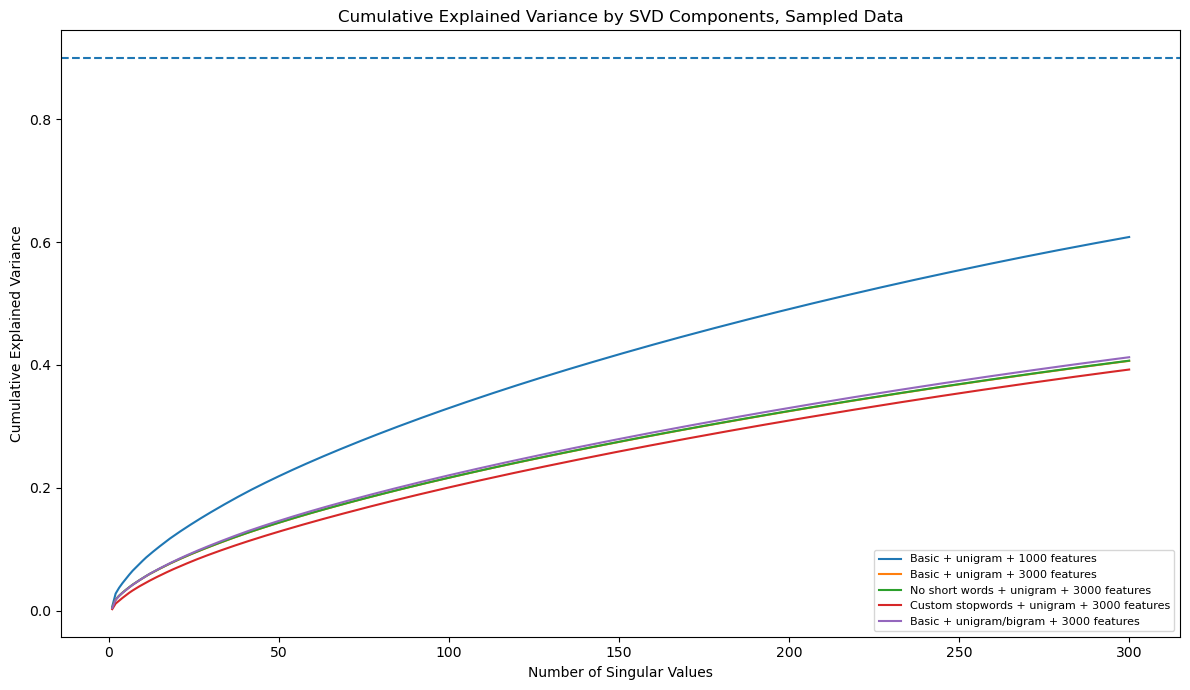

In [45]:
#plot sampled experiment results

plt.figure(figsize=(12, 7))

for experiment_name, output in saved_outputs.items():
    cumulative_variance = output["cumulative_variance"]

    plt.plot(
        range(1, len(cumulative_variance) + 1),
        cumulative_variance,
        label=experiment_name
    )

plt.axhline(0.90, linestyle="--")

plt.title("Cumulative Explained Variance by SVD Components, Sampled Data")
plt.xlabel("Number of Singular Values")
plt.ylabel("Cumulative Explained Variance")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

pick best method for sampled experiments

In [46]:
# If any experiment reaches 90%, choose the one with the fewest retained SVs.
# If none reaches 90%, choose the one with highest explained variance.

if results_df["reached_90_percent"].any():
    best_experiment_name = (
        results_df[results_df["reached_90_percent"] == True]
        .sort_values(by="retained_svs", ascending=True)
        .iloc[0]["experiment"]
    )
else:
    best_experiment_name = (
        results_df
        .sort_values(by="max_explained_variance_tested", ascending=False)
        .iloc[0]["experiment"]
    )

print("Best sampled experiment:", best_experiment_name)

best_sampled_setting = next(
    setting for setting in experiment_settings
    if setting["experiment_name"] == best_experiment_name
)

best_sampled_setting

Best sampled experiment: Basic + unigram + 1000 features


{'experiment_name': 'Basic + unigram + 1000 features',
 'text_column': 'text_basic',
 'max_features': 1000,
 'min_df': 5,
 'ngram_range': (1, 1)}

In [47]:
# Apply the highest-performing sampled method to the full merged dataset.

full_result, full_vectorizer, full_svd, full_X_tfidf, full_X_svd, full_cumvar = run_svd_experiment(
    text_data=combined_df[best_sampled_setting["text_column"]],
    experiment_name=best_sampled_setting["experiment_name"] + " applied to full dataset",
    max_features=best_sampled_setting["max_features"],
    min_df=best_sampled_setting["min_df"],
    ngram_range=best_sampled_setting["ngram_range"],
    component_cap=700
)

full_result

{'experiment': 'Basic + unigram + 1000 features applied to full dataset',
 'max_features': 1000,
 'min_df': 5,
 'ngram_range': '(1, 1)',
 'tfidf_rows': 18645,
 'tfidf_features': 1000,
 'components_tested': 700,
 'reached_90_percent': np.False_,
 'retained_svs': 700,
 'explained_variance_at_retained_svs': np.float64(0.870463117913703),
 'max_explained_variance_tested': np.float64(0.870463117913703)}

Plot full dataset SVD result

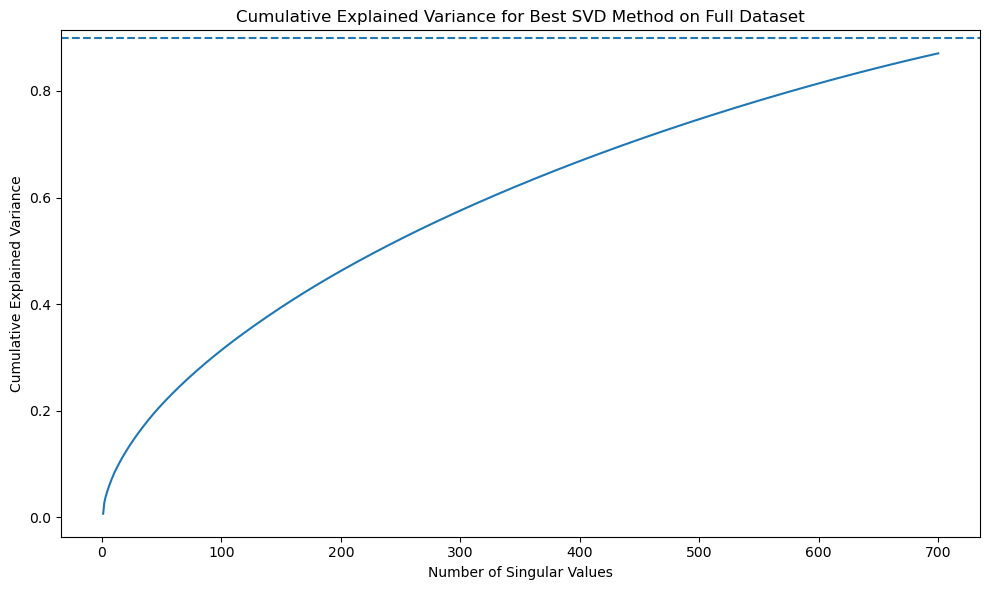

In [48]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(full_cumvar) + 1),
    full_cumvar
)

plt.axhline(0.90, linestyle="--")

plt.title("Cumulative Explained Variance for Best SVD Method on Full Dataset")
plt.xlabel("Number of Singular Values")
plt.ylabel("Cumulative Explained Variance")
plt.tight_layout()
plt.show()

Store final best model objects

In [49]:
best_vectorizer = full_vectorizer
best_svd = full_svd
best_X_tfidf = full_X_tfidf
best_X_svd = full_X_svd
best_cumulative_variance = full_cumvar
best_text_column = best_sampled_setting["text_column"]

print("Final best text column:", best_text_column)
print("Final full dataset result:")
full_result

Final best text column: text_basic
Final full dataset result:


{'experiment': 'Basic + unigram + 1000 features applied to full dataset',
 'max_features': 1000,
 'min_df': 5,
 'ngram_range': '(1, 1)',
 'tfidf_rows': 18645,
 'tfidf_features': 1000,
 'components_tested': 700,
 'reached_90_percent': np.False_,
 'retained_svs': 700,
 'explained_variance_at_retained_svs': np.float64(0.870463117913703),
 'max_explained_variance_tested': np.float64(0.870463117913703)}

Create TF-IDF dataframe for final model

In [50]:
best_tfidf_df = pd.DataFrame.sparse.from_spmatrix(
    best_X_tfidf,
    columns=best_vectorizer.get_feature_names_out()
)

best_tfidf_df.head()

,abilities,ability,able,achieve,acquire,action,actions,active,ad,add,...,workers,working,works,world,worlds,worth,written,year,years,young
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0.49544,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0.079382,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [51]:
#optional with titles
best_tfidf_df_with_titles = pd.concat(
    [
        combined_df[["title", "type"]].reset_index(drop=True),
        best_tfidf_df.reset_index(drop=True)
    ],
    axis=1
)

best_tfidf_df_with_titles.head()

,title,type,abilities,ability,able,achieve,acquire,action,actions,active,...,workers,working,works,world,worlds,worth,written,year,years,young
0,The Strange,TTRPG,0,0,0,0,0,0,0,0,...,0,0,0,0,0.49544,0,0,0,0,0
1,InSpectres,TTRPG,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,Dungeons & Dragons Expert Set,TTRPG,0,0,0.079382,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,The Character Compendium,TTRPG,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,The Elves of Alfheim,TTRPG,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Create SVD semantic vectors dataframe

In [52]:
best_svd_df = pd.DataFrame(
    best_X_svd,
    columns=[f"SV {i+1}" for i in range(best_X_svd.shape[1])]
)

best_svd_df_with_titles = pd.concat(
    [
        combined_df[["title", "type"]].reset_index(drop=True),
        best_svd_df.reset_index(drop=True)
    ],
    axis=1
)

best_svd_df_with_titles.head()

,title,type,SV 1,SV 2,SV 3,SV 4,SV 5,SV 6,SV 7,SV 8,...,SV 691,SV 692,SV 693,SV 694,SV 695,SV 696,SV 697,SV 698,SV 699,SV 700
0,The Strange,TTRPG,0.107399,-0.104504,0.018726,0.081866,-0.067319,-0.047141,-0.093223,-0.003538,...,0.023679,-0.010019,-0.001903,0.000497,-0.013970,-0.007106,-0.032630,-0.005020,0.018144,-0.008290
1,InSpectres,TTRPG,0.219407,-0.036888,-0.059733,-0.112204,-0.043274,-0.050386,-0.055216,-0.050020,...,-0.035189,-0.023205,0.019756,-0.006623,-0.004179,-0.018228,-0.011424,0.009447,0.009368,0.014889
2,Dungeons & Dragons Expert Set,TTRPG,0.251008,-0.164331,0.023666,-0.106225,0.229565,0.017188,-0.016515,0.075656,...,0.015776,0.012646,-0.005254,-0.008854,-0.001709,0.015848,-0.007526,0.007220,-0.003361,-0.005583
3,The Character Compendium,TTRPG,0.202576,-0.200946,0.087851,-0.183995,0.081420,0.137365,0.095420,-0.030453,...,-0.017356,-0.000093,-0.014638,-0.007524,0.009409,-0.002348,-0.032058,0.000920,0.004535,0.006268
4,The Elves of Alfheim,TTRPG,0.166336,-0.075710,0.004446,0.049428,-0.028184,0.015593,0.014581,-0.016958,...,0.010723,0.010544,-0.011012,-0.007770,-0.014000,-0.024785,0.078835,0.099149,0.036476,0.016244


In [53]:
# IR search function

def search_games(query, text_preprocessor, vectorizer, svd, game_vectors, df, top_n=10):
    """
    Search for games similar to a user query using TF-IDF + SVD vectors.
    """

    clean_query = text_preprocessor(query)

    query_tfidf = vectorizer.transform([clean_query])
    query_svd = svd.transform(query_tfidf)

    similarities = cosine_similarity(query_svd, game_vectors).flatten()

    results = df[[
        "title",
        "type",
        "description",
        "average_score",
        "number_of_reviews"
    ]].copy()

    results["similarity"] = similarities

    return results.sort_values("similarity", ascending=False).head(top_n)

In [54]:
# Map final preprocessor

preprocessor_map = {
    "text_basic": preprocess_basic,
    "text_no_short": preprocess_no_short_words,
    "text_custom_stopwords": preprocess_remove_game_words
}

best_preprocessor = preprocessor_map[best_text_column]

print("Best preprocessor:", best_text_column)

Best preprocessor: text_basic


test IR queries

In [55]:
search_games(
    query="fantasy adventure with magic dragons and quests",
    text_preprocessor=best_preprocessor,
    vectorizer=best_vectorizer,
    svd=best_svd,
    game_vectors=best_X_svd,
    df=combined_df,
    top_n=10
)

,title,type,description,average_score,number_of_reviews,similarity
2908,Dragon Keep,TTRPG,From the back cover: The good dragons of Krynn...,6.20000,5.0,0.507913
4861,A Magical Medley (Fudge),TTRPG,A Magical Medley is a magic-rich supplement fo...,7.83333,6.0,0.498044
3316,Fantasy Hero 4th Edition,TTRPG,Publisher's description: Fantasy comes to the ...,6.80769,13.0,0.497391
5519,Dragonlance Miniature Reprints: Volume 1 – DL1...,TTRPG,"User summaryThis is a box containing eight 4"" ...",7.00000,2.0,0.490866
1090,Adventuring Party 2013,TTRPG,Figure Set for Adventure Gaming From the back ...,0.00000,0.0,0.485452
7346,Fantasy Hero 6th Edition,TTRPG,Back Cover: WONDROUS WORLDS OF FANTASY! Fantas...,8.21429,7.0,0.473012
228,Dungeons & Dragons Basic Rulebook (Second Edit...,TTRPG,From the back of the book: DUNGEONS & DRAGONS ...,7.99107,28.0,0.469310
5639,Dragonlance Miniature Reprints: Volume 2 – DL9...,TTRPG,"User summaryThis is a box containing eight 4"" ...",7.00000,1.0,0.465277
3145,The Art of the Advanced Dungeons & Dragons Fan...,TTRPG,The Art of the Advanced Dungeons & Dragons Fan...,0.00000,0.0,0.462070
8884,Wizards & Spells: A Young Adventurer's Guide,TTRPG,Publisher's blurb: An immersive illustrated pr...,2.00000,1.0,0.459898


In [56]:
search_games(
    query="horror mystery investigation supernatural monsters",
    text_preprocessor=best_preprocessor,
    vectorizer=best_vectorizer,
    svd=best_svd,
    game_vectors=best_X_svd,
    df=combined_df,
    top_n=10
)

,title,type,description,average_score,number_of_reviews,similarity
6338,Ghost Stories: Horror Mystery Adventures,TTRPG,From publisher blurb: Ghost Stories is predica...,7.00000,1.0,0.535982
7646,GURPS Horror (Fourth Edition),TTRPG,It's back . . . and the fear has grown! GURPS ...,8.28125,16.0,0.507320
7323,Supernatural Adventures,TTRPG,"You've Got Work To Do! Ghosts, demons, and mon...",6.00000,1.0,0.487542
6919,Mortal Coil,TTRPG,Mortal Coil is a supernatural role-playing gam...,8.00000,5.0,0.463105
5260,Nightmares of Mine,TTRPG,[Back cover] Horror has been with us for as lo...,8.73333,12.0,0.443819
1953,Bureau 13: Stalking the Night Fantastic (2nd E...,TTRPG,From the introduction: The history of the huma...,0.00000,0.0,0.432868
2584,Beyond the Supernatural (First Edition),TTRPG,From the back of the book: A Role-Playing Game...,6.00000,26.0,0.424313
3699,Bureau 13: Stalking the Night Fantastic (3rd E...,TTRPG,An modern horror rpg-- this edition makes chan...,7.00000,10.0,0.409631
1578,Bureau 13: Stalking the Night Fantastic (1st E...,TTRPG,"Publisher's Blurb: In the early 1860's, the go...",6.90909,11.0,0.409229
9645,Witch: Fated Souls 2E,TTRPG,From publisher blurb: Witch: Fated Souls Secon...,0.00000,0.0,0.407441


In [57]:
search_games(
    query="science fiction space exploration cyberpunk future technology",
    text_preprocessor=best_preprocessor,
    vectorizer=best_vectorizer,
    svd=best_svd,
    game_vectors=best_X_svd,
    df=combined_df,
    top_n=10
)

,title,type,description,average_score,number_of_reviews,similarity
3268,Buck Rogers Boxed Set XXVc,TTRPG,Buck Rogers and the forces of the New Earth Or...,7.61765,17.0,0.565046
984,Space Opera,TTRPG,Space Opera is a science-fiction role-playing ...,6.29200,25.0,0.553517
4114,Tradition Book: Sons of Ether (1st Edition),TTRPG,"""Gentlemen, I give you the amazing Electrodyna...",6.91176,17.0,0.492145
173,Genesys Core Rulebook,TTRPG,Description from the publisher: Face down a dr...,8.09615,52.0,0.488089
9133,Cepheus Deluxe,TTRPG,Publisher's blurb: Starships riding fire acros...,8.00000,5.0,0.484050
6384,OGL Steampunk,TTRPG,From the back of the book: This is the world o...,5.00000,2.0,0.483244
3367,GURPS Aliens,TTRPG,"From the cover: ""Nonhuman Races for Science Fi...",6.40909,11.0,0.477913
9231,Death in Space,TTRPG,From the kickstarter: Engage in power struggle...,7.20000,20.0,0.466659
9046,Coyote & Crow,TTRPG,"Publisher's description: Coyote & Crow, the Ro...",6.80000,5.0,0.455556
3026,GURPS Space (Second Edition),TTRPG,"Subtitle: ""Roleplaying in the Worlds of Tomorr...",7.04545,33.0,0.452657


In [58]:
search_games(
    query="strategy war civilization resource management combat",
    text_preprocessor=best_preprocessor,
    vectorizer=best_vectorizer,
    svd=best_svd,
    game_vectors=best_X_svd,
    df=combined_df,
    top_n=10
)

,title,type,description,average_score,number_of_reviews,similarity
9892,Sid Meier's Civilization: The Board Game,Board Game,Please note: this entry covers the 2010 releas...,7.40000,NaN,0.478096
11901,Age of Civilization,Board Game,"In the Age of Civilization, you must lead your...",7.13000,NaN,0.411027
11233,Age of Renaissance,Board Game,A game that is often described as a semi-seque...,7.10000,NaN,0.401036
12577,Mega Civilization,Board Game,Description from the publisher:&#10;&#10;Mega ...,8.24000,NaN,0.399607
10188,Civilization,Board Game,Civilization is a game of skill for 2 to 7 pla...,7.50000,NaN,0.375069
10955,Sid Meier's Civilization: The Boardgame,Board Game,This entry covers the 2002 release of Sid Meie...,5.60000,NaN,0.367725
18014,"Outreach: The Conquest of the Galaxy, 3000AD",Board Game,"Simulates civilization development, intra-gala...",6.56000,NaN,0.365642
15206,Tribes: Early Civilization,Board Game,Guide your tribe in its struggles to survive a...,6.52000,NaN,0.355709
4186,GURPS Aztecs,TTRPG,Sacrifice and Glory in a Lost Civilization,7.34615,13.0,0.347264
10563,Vinci,Board Game,Along the lines of History of the World by The...,7.08000,NaN,0.342374


In [59]:
summary_table = pd.concat(
    [
        results_df.assign(stage="sampled_experiment"),
        pd.DataFrame([full_result]).assign(stage="full_dataset_best_method")
    ],
    ignore_index=True
)

summary_table

,experiment,max_features,min_df,ngram_range,tfidf_rows,tfidf_features,components_tested,reached_90_percent,retained_svs,explained_variance_at_retained_svs,max_explained_variance_tested,stage
0,Basic + unigram + 1000 features,1000,5,"(1, 1)",5000,1000,300,False,300,0.608388,0.608388,sampled_experiment
1,Basic + unigram + 3000 features,3000,5,"(1, 1)",5000,3000,300,False,300,0.406690,0.406690,sampled_experiment
2,No short words + unigram + 3000 features,3000,5,"(1, 1)",5000,3000,300,False,300,0.407023,0.407023,sampled_experiment
3,Custom stopwords + unigram + 3000 features,3000,5,"(1, 1)",5000,3000,300,False,300,0.392610,0.392610,sampled_experiment
4,Basic + unigram/bigram + 3000 features,3000,5,"(1, 2)",5000,3000,300,False,300,0.412636,0.412636,sampled_experiment
5,Basic + unigram + 1000 features applied to ful...,1000,5,"(1, 1)",18645,1000,700,False,700,0.870463,0.870463,full_dataset_best_method


## Findings

After testing multiple TF-IDF + SVD setups on a 5,000-row sample, the highest-performing setup was Basic preprocessing + unigram TF-IDF + 1000 features. This setup preserved the most explained variance among the sampled experiments. I then applied this setup to the full merged dataset of 15,165 games. With 700 retained singular values, the model preserved about 87.56% explained variance. Although it did not fully reach 90%, it was close while still being manageable to run.

For the IR test, the sample queries returned mostly relevant results based on their themes, such as fantasy, horror, science fiction, and strategy/civilization.